In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# 분석 도구 불러오기
import pandas as pd        # 표 형태로 데이터를 다루는 도구
import numpy as np         # 수학 계산 도구
import matplotlib.pyplot as plt # 기본 그래프 그리기 도구
import seaborn as sns      # 더 예쁜 고급 그래프 그리기 도구
from scipy import stats    # 통계 검정 도구

# 한글 폰트 설정 (그래프에서 한글 깨짐 방지)
plt.rc('font', family='NanumBarunGothic')
print("필요한 라이브러리를 성공적으로 불러왔습니다!")



필요한 라이브러리를 성공적으로 불러왔습니다!


In [3]:
# 1. 구글 드라이브의 train.csv 파일 읽기
file_path = '/content/drive/MyDrive/train.csv'
df = pd.read_csv(file_path)

# 2. 데이터 크기 확인 (행, 열)
print("데이터 크기 (행, 열):", df.shape)

# 3. 맨 위 5개 행 미리보기
df.head()

데이터 크기 (행, 열): (87159, 16)


,ID,Age,Gender,Country,Race,Family_Background,Radiation_History,Iodine_Deficiency,Smoke,Weight_Risk,Diabetes,Nodule_Size,TSH_Result,T4_Result,T3_Result,Cancer
0,TRAIN_00000,80,M,CHN,ASN,Positive,Exposed,Sufficient,Non-Smoker,Not Obese,No,0.650355,2.784735,6.744603,2.575820,1
1,TRAIN_00001,37,M,NGA,ASN,Positive,Unexposed,Sufficient,Smoker,Obese,No,2.950430,0.911624,7.303305,2.505317,1
2,TRAIN_00002,71,M,CHN,MDE,Positive,Unexposed,Sufficient,Non-Smoker,Not Obese,Yes,2.200023,0.717754,11.137459,2.381080,0
3,TRAIN_00003,40,F,IND,HSP,Negative,Unexposed,Sufficient,Non-Smoker,Obese,No,3.370796,6.846380,10.175254,0.753023,0
4,TRAIN_00004,53,F,CHN,CAU,Negative,Unexposed,Sufficient,Non-Smoker,Not Obese,No,4.230048,0.439519,7.194450,0.569356,1


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


현재 적용된 폰트: ['NanumGothic']


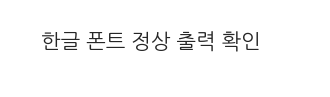

In [4]:
# ===== [셀 1] 환경 설정 (완전 초기화 버전) =====
from google.colab import drive
drive.mount('/content/drive')

# 폰트 설치
!sudo apt-get -qq -y install fonts-nanum

# matplotlib 폰트 캐시 완전 삭제 (중요)
import shutil, os
cache_dir = os.path.expanduser('~/.cache/matplotlib')
if os.path.exists(cache_dir):
    shutil.rmtree(cache_dir)

import matplotlib
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

# 폰트 매니저 강제 재빌드
fm._load_fontmanager(try_read_cache=False)

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'  # BarunGothic 대신 NanumGothic 사용
fm.fontManager.addfont(font_path)
font_name = fm.FontProperties(fname=font_path).get_name()

# 전역으로 강제 고정 (핵심: rc()가 아니라 rcParams 딕셔너리를 직접 업데이트)
matplotlib.rcParams['font.family'] = font_name
matplotlib.rcParams['axes.unicode_minus'] = False

import pandas as pd
import numpy as np
import seaborn as sns
from scipy import stats
from scipy.stats import mannwhitneyu, chi2_contingency, skew

sns.set_style('whitegrid')
# seaborn 스타일 적용 후 폰트가 초기화될 수 있으므로 다시 한번 강제 지정
matplotlib.rcParams['font.family'] = font_name
plt.rcParams['figure.figsize'] = (10, 6)

print(f"현재 적용된 폰트: {matplotlib.rcParams['font.family']}")

# 최종 확인 테스트
fig, ax = plt.subplots(figsize=(4, 1))
ax.text(0.1, 0.5, '한글 폰트 정상 출력 확인', fontsize=15)
ax.axis('off')
plt.show()

In [5]:
# ===== [셀 2] 데이터 로드 및 프로파일링 =====
# train.csv가 MyDrive 바로 아래에 있는 경우
DATA_PATH = '/content/drive/MyDrive/train.csv'

df = pd.read_csv(DATA_PATH)

print(f"데이터 형태(Shape): {df.shape[0]}행 x {df.shape[1]}열\n")

# 결측치 / 데이터 타입 / Unique 값 수를 하나의 요약 테이블로 정리
profile = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    '결측치_개수': df.isnull().sum(),
    '결측치_비율(%)': (df.isnull().sum() / len(df) * 100).round(2),
    'Unique_개수': df.nunique(),
    '샘플값': [df[col].dropna().unique()[:3] for col in df.columns]
})

profile = profile.sort_values('결측치_비율(%)', ascending=False)
print("=== 컬럼별 프로파일링 요약 ===")
display(profile)

print("\n=== 기초 통계량 (수치형) ===")
display(df.describe().T)

print("\n=== 데이터 상위 5행 ===")
display(df.head())

데이터 형태(Shape): 87159행 x 16열

=== 컬럼별 프로파일링 요약 ===


,dtype,결측치_개수,결측치_비율(%),Unique_개수,샘플값
ID,object,0,0.0,87159,"[TRAIN_00000, TRAIN_00001, TRAIN_00002]"
Age,int64,0,0.0,75,"[80, 37, 71]"
Gender,object,0,0.0,2,"[M, F]"
Country,object,0,0.0,10,"[CHN, NGA, IND]"
Race,object,0,0.0,5,"[ASN, MDE, HSP]"
Family_Background,object,0,0.0,2,"[Positive, Negative]"
Radiation_History,object,0,0.0,2,"[Exposed, Unexposed]"
Iodine_Deficiency,object,0,0.0,2,"[Sufficient, Deficient]"
Smoke,object,0,0.0,2,"[Non-Smoker, Smoker]"
Weight_Risk,object,0,0.0,2,"[Not Obese, Obese]"



=== 기초 통계량 (수치형) ===


,count,mean,std,min,25%,50%,75%,max
Age,87159.0,50.860244,21.638687,14.0,32.000000,51.000000,70.000000,88.0
Nodule_Size,87159.0,2.508098,1.441928,0.0,1.270332,2.520941,3.760938,5.0
TSH_Result,87159.0,5.056871,2.861229,0.1,2.582845,5.059085,7.541586,10.0
T4_Result,87159.0,8.248796,2.165975,4.5,6.372031,8.236789,10.126981,12.0
T3_Result,87159.0,2.005002,0.867013,0.5,1.254836,2.004101,2.758032,3.5
Cancer,87159.0,0.119999,0.324962,0.0,0.000000,0.000000,0.000000,1.0



=== 데이터 상위 5행 ===


,ID,Age,Gender,Country,Race,Family_Background,Radiation_History,Iodine_Deficiency,Smoke,Weight_Risk,Diabetes,Nodule_Size,TSH_Result,T4_Result,T3_Result,Cancer
0,TRAIN_00000,80,M,CHN,ASN,Positive,Exposed,Sufficient,Non-Smoker,Not Obese,No,0.650355,2.784735,6.744603,2.575820,1
1,TRAIN_00001,37,M,NGA,ASN,Positive,Unexposed,Sufficient,Smoker,Obese,No,2.950430,0.911624,7.303305,2.505317,1
2,TRAIN_00002,71,M,CHN,MDE,Positive,Unexposed,Sufficient,Non-Smoker,Not Obese,Yes,2.200023,0.717754,11.137459,2.381080,0
3,TRAIN_00003,40,F,IND,HSP,Negative,Unexposed,Sufficient,Non-Smoker,Obese,No,3.370796,6.846380,10.175254,0.753023,0
4,TRAIN_00004,53,F,CHN,CAU,Negative,Unexposed,Sufficient,Non-Smoker,Not Obese,No,4.230048,0.439519,7.194450,0.569356,1


=== 클래스 분포 요약 ===


,Class,개수,비율(%)
0,0,76700,88.0
1,1,10459,12.0



Class Imbalance Ratio (다수클래스:소수클래스) = 7.33 : 1


/tmp/ipykernel_1761/3643415544.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=target_col, data=df, palette=colors, ax=axes[1])


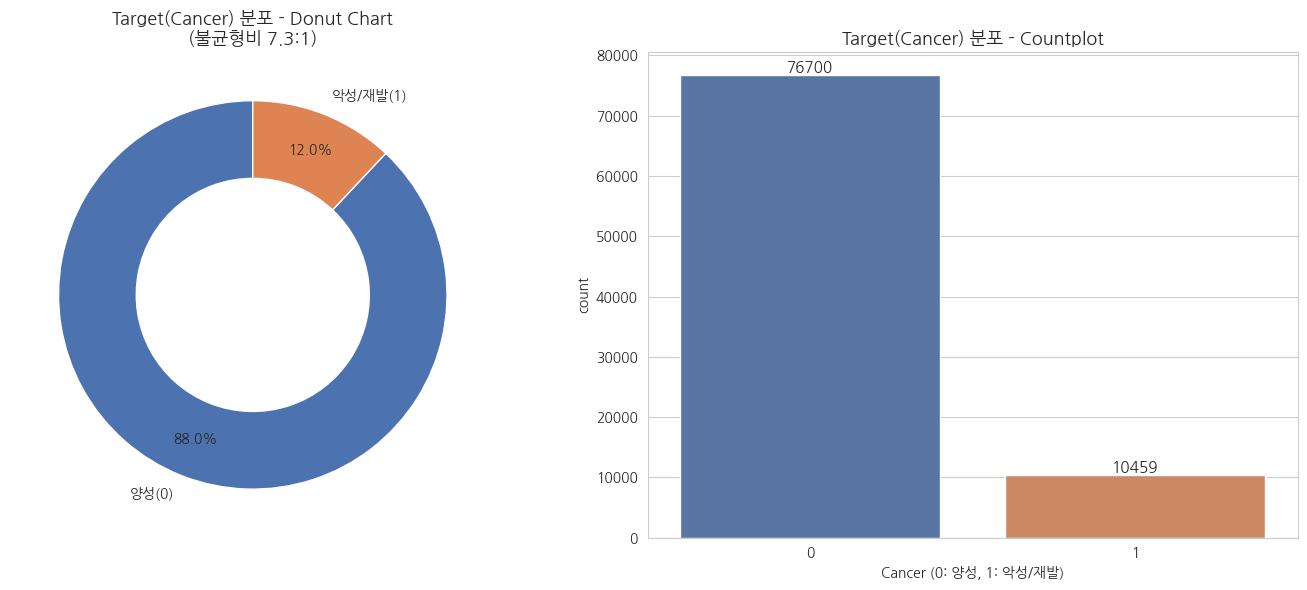

In [6]:
# ===== [셀 3] Target(Cancer) 클래스 불균형 분석 =====
target_col = 'Cancer'

class_counts = df[target_col].value_counts().sort_index()
class_ratio = df[target_col].value_counts(normalize=True).sort_index() * 100

# Class Imbalance Ratio (다수:소수 = X:1)
majority = class_counts.max()
minority = class_counts.min()
imbalance_ratio = majority / minority

summary_df = pd.DataFrame({
    'Class': class_counts.index,
    '개수': class_counts.values,
    '비율(%)': class_ratio.values.round(2)
})
print("=== 클래스 분포 요약 ===")
display(summary_df)
print(f"\nClass Imbalance Ratio (다수클래스:소수클래스) = {imbalance_ratio:.2f} : 1")

# 시각화: Donut Chart + Countplot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Donut Chart
colors = ['#4C72B0', '#DD8452']
wedges, texts, autotexts = axes[0].pie(
    class_counts.values,
    labels=[f'{"양성(0)" if i==0 else "악성/재발(1)"}' for i in class_counts.index],
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    pctdistance=0.8,
    wedgeprops=dict(width=0.4)
)
axes[0].set_title(f'Target(Cancer) 분포 - Donut Chart\n(불균형비 {imbalance_ratio:.1f}:1)', fontsize=13)

# Countplot
sns.countplot(x=target_col, data=df, palette=colors, ax=axes[1])
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())}',
                      (p.get_x() + p.get_width()/2, p.get_height()),
                      ha='center', va='bottom', fontsize=11)
axes[1].set_title('Target(Cancer) 분포 - Countplot', fontsize=13)
axes[1].set_xlabel('Cancer (0: 양성, 1: 악성/재발)')

plt.tight_layout()
plt.show()

=== Mann-Whitney U Test 결과 (Cancer 0 vs 1 그룹 비교) ===


,변수,U-statistic,p-value,유의성(p<0.05)
0,Age,401726763.0,0.79596,유의하지 않음
1,Nodule_Size,400333171.5,0.74990,유의하지 않음
2,TSH_Result,406963140.0,0.01519,유의함 *
3,T4_Result,398747813.5,0.32929,유의하지 않음
4,T3_Result,403623131.0,0.29641,유의하지 않음


/tmp/ipykernel_1761/2177841831.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x=target_col, y=col, ax=axes[1, i], palette=colors)
/tmp/ipykernel_1761/2177841831.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x=target_col, y=col, ax=axes[1, i], palette=colors)
/tmp/ipykernel_1761/2177841831.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x=target_col, y=col, ax=axes[1, i], palette=colors)
/tmp/ipykernel_1761/2177841831.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is dep

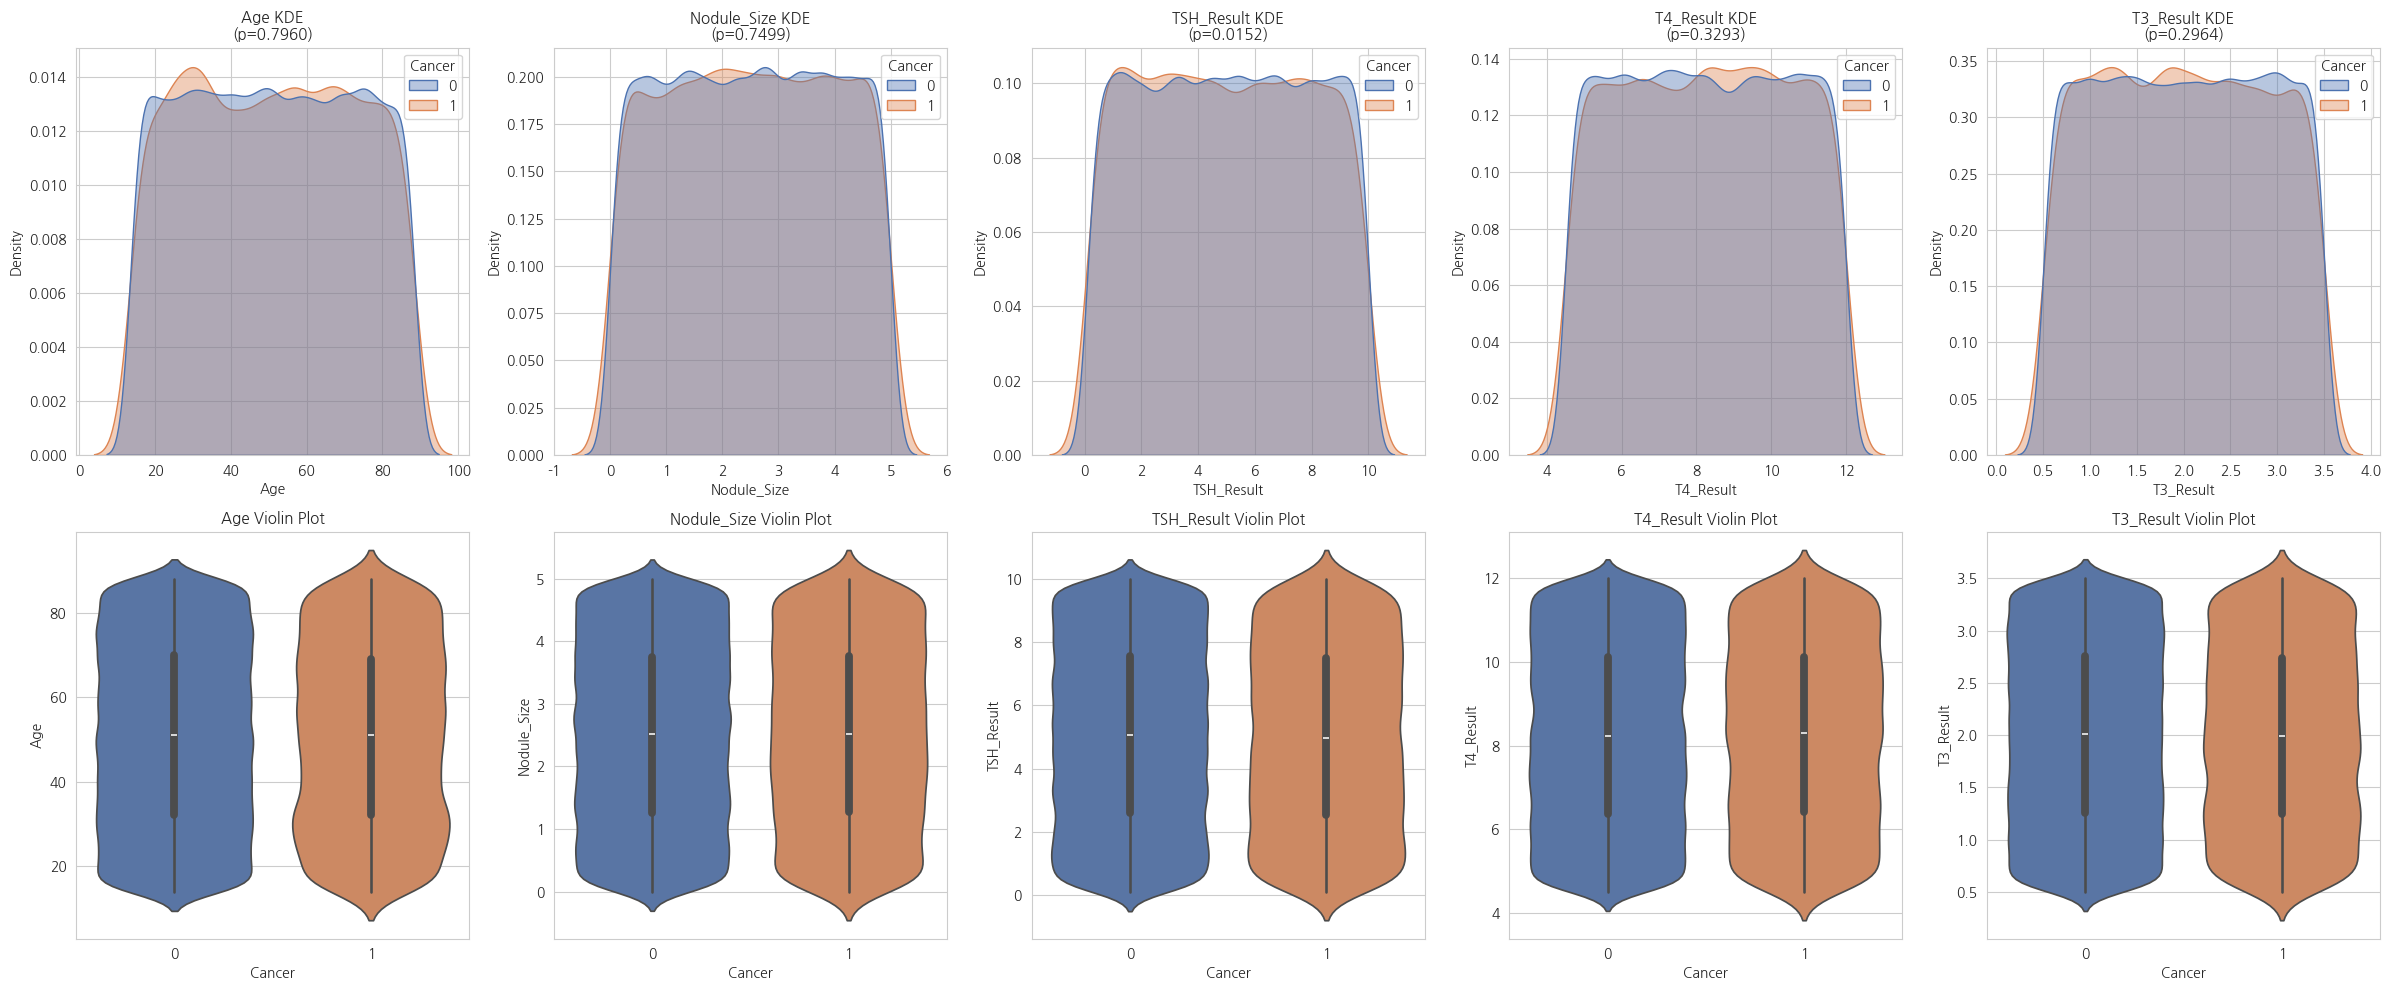

In [7]:
# ===== [셀 4] 수치형 변수 Mann-Whitney U Test + KDE/Violin =====
num_cols = ['Age', 'Nodule_Size', 'TSH_Result', 'T4_Result', 'T3_Result']

mwu_results = []
for col in num_cols:
    group0 = df.loc[df[target_col] == 0, col].dropna()
    group1 = df.loc[df[target_col] == 1, col].dropna()
    stat, p_value = mannwhitneyu(group0, group1, alternative='two-sided')
    mwu_results.append({
        '변수': col,
        'U-statistic': round(stat, 2),
        'p-value': round(p_value, 5),
        '유의성(p<0.05)': '유의함 *' if p_value < 0.05 else '유의하지 않음'
    })

mwu_df = pd.DataFrame(mwu_results)
print("=== Mann-Whitney U Test 결과 (Cancer 0 vs 1 그룹 비교) ===")
display(mwu_df)

# KDE Density Plot & Violin Plot 서브플롯
fig, axes = plt.subplots(2, 5, figsize=(24, 10))

for i, col in enumerate(num_cols):
    # KDE
    sns.kdeplot(data=df, x=col, hue=target_col, fill=True,
                common_norm=False, alpha=0.4, ax=axes[0, i], palette=colors)
    p_val = mwu_df.loc[mwu_df['변수'] == col, 'p-value'].values[0]
    axes[0, i].set_title(f'{col} KDE\n(p={p_val:.4f})', fontsize=11)

    # Violin
    sns.violinplot(data=df, x=target_col, y=col, ax=axes[1, i], palette=colors)
    axes[1, i].set_title(f'{col} Violin Plot', fontsize=11)
    axes[1, i].set_xlabel('Cancer')

plt.tight_layout()
plt.show()

=== 카이제곱 검정 & Odds Ratio 요약표 ===


,변수,Chi2,p-value,유의성(p<0.05),Odds Ratio
0,Radiation_History,488.618,0.00000,유의함 *,1.772
1,Family_Background,1000.577,0.00000,유의함 *,0.511
2,Iodine_Deficiency,556.357,0.00000,유의함 *,1.693
5,Weight_Risk,0.435,0.50931,유의하지 않음,0.985
4,Smoke,0.035,0.85238,유의하지 않음,0.995
3,Gender,0.031,0.86133,유의하지 않음,0.996
6,Diabetes,0.005,0.94274,유의하지 않음,0.998


/tmp/ipykernel_1761/1021222487.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rate_df, x=col, y=target_col, ax=axes[i], palette='viridis')
/tmp/ipykernel_1761/1021222487.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rate_df, x=col, y=target_col, ax=axes[i], palette='viridis')
/tmp/ipykernel_1761/1021222487.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rate_df, x=col, y=target_col, ax=axes[i], palette='viridis')
/tmp/ipykernel_1761/1021222487.py:44: FutureWarning: 

Passing `palette` without assigning `hue` 

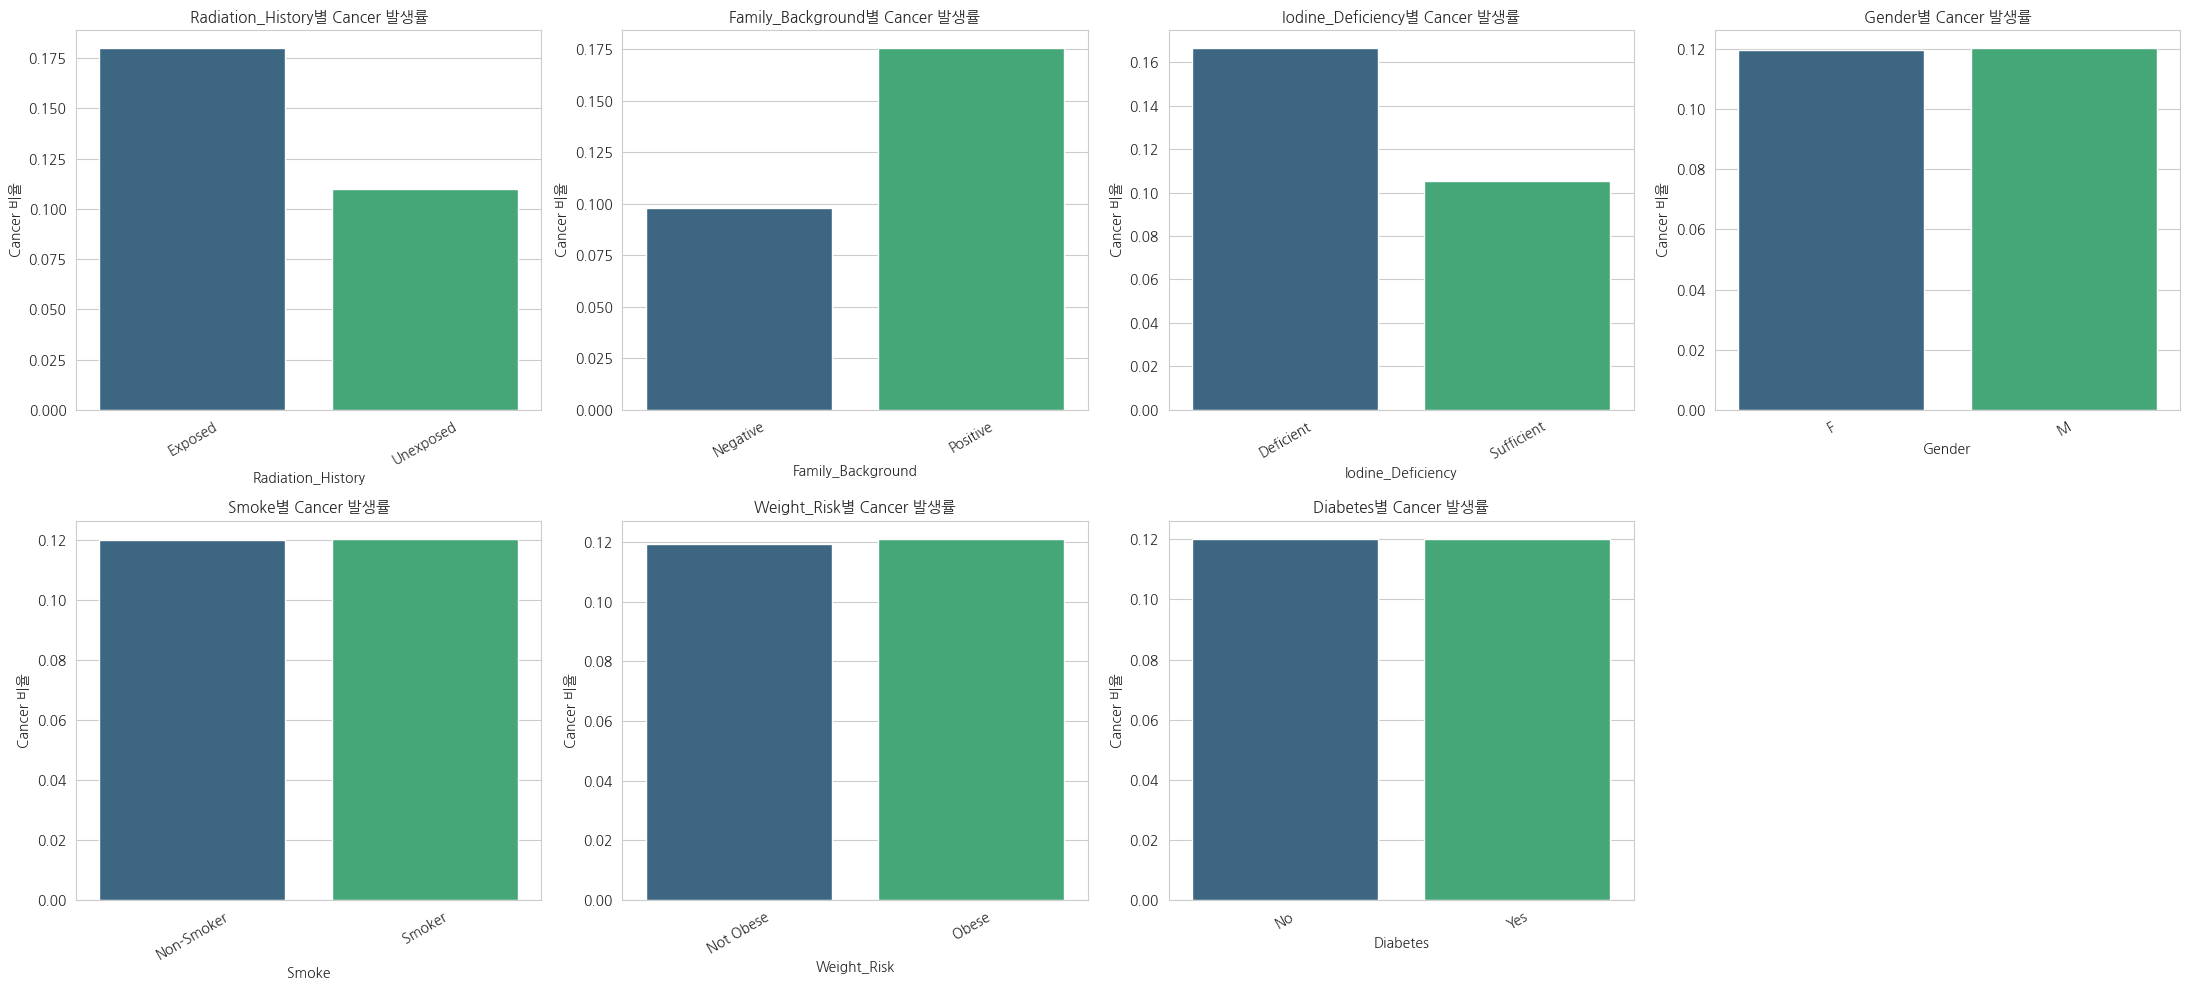

In [8]:
# ===== [셀 5] 범주형 변수 카이제곱 검정 & Odds Ratio =====
risk_cat_cols = ['Radiation_History', 'Family_Background', 'Iodine_Deficiency',
                  'Gender', 'Smoke', 'Weight_Risk', 'Diabetes']

chi_results = []

for col in risk_cat_cols:
    if col not in df.columns:
        continue
    contingency = pd.crosstab(df[col], df[target_col])
    chi2, p_val, dof, expected = chi2_contingency(contingency)

    # Odds Ratio 계산 (2x2 테이블 기준, 범주가 2개일 때만 정확 계산)
    or_value = np.nan
    if contingency.shape[0] == 2:
        # 표준 2x2 배치: [ [a, b], [c, d] ] -> OR = (a*d) / (b*c)
        a, b = contingency.iloc[0, 0], contingency.iloc[0, 1]
        c, d = contingency.iloc[1, 0], contingency.iloc[1, 1]
        # 0으로 나누는 것 방지를 위한 Haldane-Anscombe 보정
        if 0 in [a, b, c, d]:
            a, b, c, d = a+0.5, b+0.5, c+0.5, d+0.5
        or_value = (b * c) / (a * d) if (a * d) != 0 else np.nan

    chi_results.append({
        '변수': col,
        'Chi2': round(chi2, 3),
        'p-value': round(p_val, 5),
        '유의성(p<0.05)': '유의함 *' if p_val < 0.05 else '유의하지 않음',
        'Odds Ratio': round(or_value, 3) if not np.isnan(or_value) else '해당없음(범주>2)'
    })

chi_df = pd.DataFrame(chi_results).sort_values('p-value')
print("=== 카이제곱 검정 & Odds Ratio 요약표 ===")
display(chi_df)

# 시각화: 유의미한 위험요인별 Cancer 비율 Barplot
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for i, col in enumerate(risk_cat_cols):
    if col not in df.columns or i >= len(axes):
        continue
    rate_df = df.groupby(col)[target_col].mean().reset_index()
    sns.barplot(data=rate_df, x=col, y=target_col, ax=axes[i], palette='viridis')
    axes[i].set_title(f'{col}별 Cancer 발생률', fontsize=11)
    axes[i].set_ylabel('Cancer 비율')
    axes[i].tick_params(axis='x', rotation=30)

# 빈 서브플롯 숨김
for j in range(len(risk_cat_cols), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

=== 왜도 및 IQR 이상치 진단표 ===


,변수,Skewness,Log변환_권장(|Skew|>1),IQR_하한,IQR_상한,이상치_개수,이상치_비율(%)
0,Age,0.006,불필요,-25.00,127.00,0,0.0
1,Nodule_Size,-0.007,불필요,-2.47,7.50,0,0.0
2,TSH_Result,-0.000,불필요,-4.86,14.98,0,0.0
3,T4_Result,0.002,불필요,0.74,15.76,0,0.0
4,T3_Result,-0.000,불필요,-1.00,5.01,0,0.0


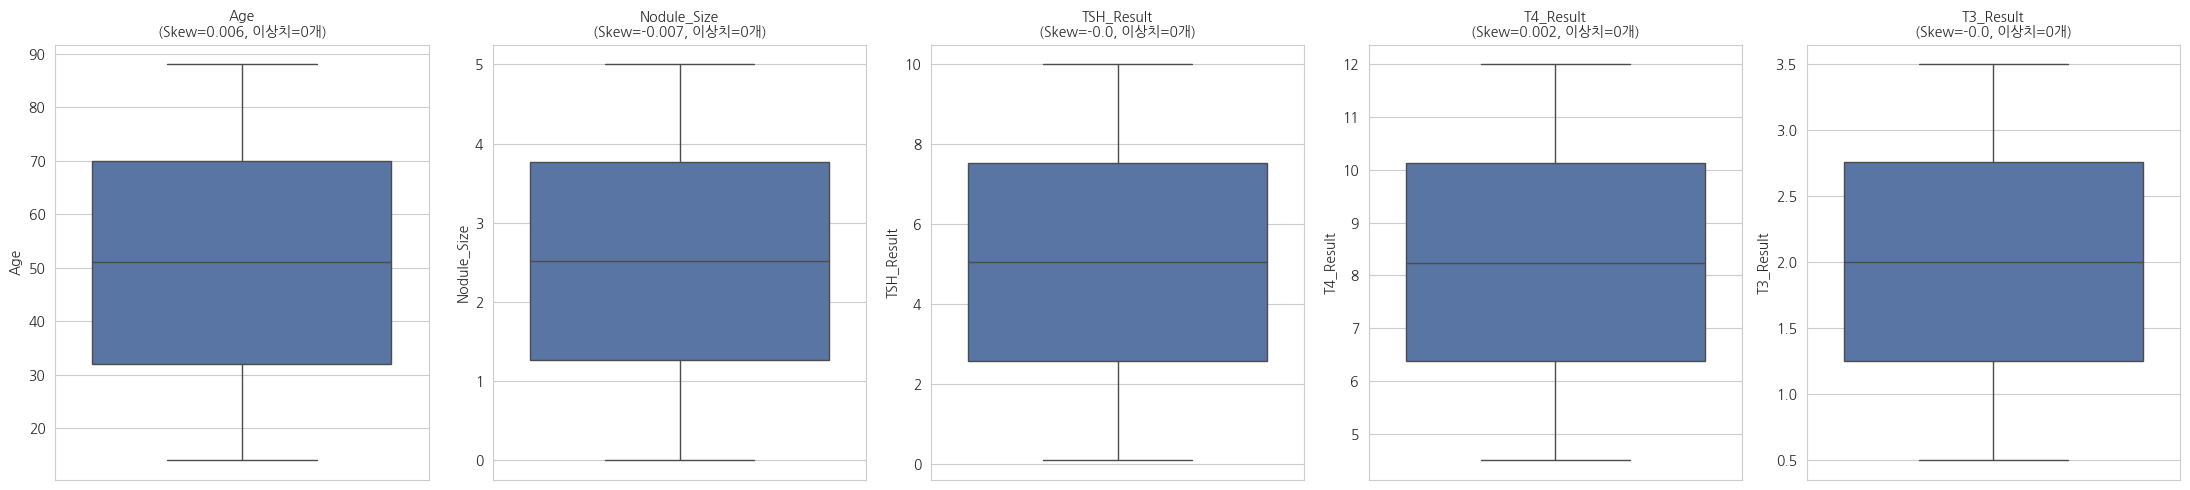

In [9]:
# ===== [셀 6] 왜도(Skewness) 및 IQR 이상치 진단 =====
diagnostic_results = []

for col in num_cols:
    data = df[col].dropna()
    col_skew = skew(data)

    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    outliers = data[(data < lower) | (data > upper)]

    diagnostic_results.append({
        '변수': col,
        'Skewness': round(col_skew, 3),
        'Log변환_권장(|Skew|>1)': '권장' if abs(col_skew) > 1 else '불필요',
        'IQR_하한': round(lower, 2),
        'IQR_상한': round(upper, 2),
        '이상치_개수': len(outliers),
        '이상치_비율(%)': round(len(outliers) / len(data) * 100, 2)
    })

diag_df = pd.DataFrame(diagnostic_results)
print("=== 왜도 및 IQR 이상치 진단표 ===")
display(diag_df)

# Boxplot으로 이상치 시각적 확인
fig, axes = plt.subplots(1, len(num_cols), figsize=(22, 5))
for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='#4C72B0')
    row = diag_df[diag_df['변수'] == col].iloc[0]
    axes[i].set_title(f"{col}\n(Skew={row['Skewness']}, 이상치={row['이상치_개수']}개)", fontsize=10)

plt.tight_layout()
plt.show()

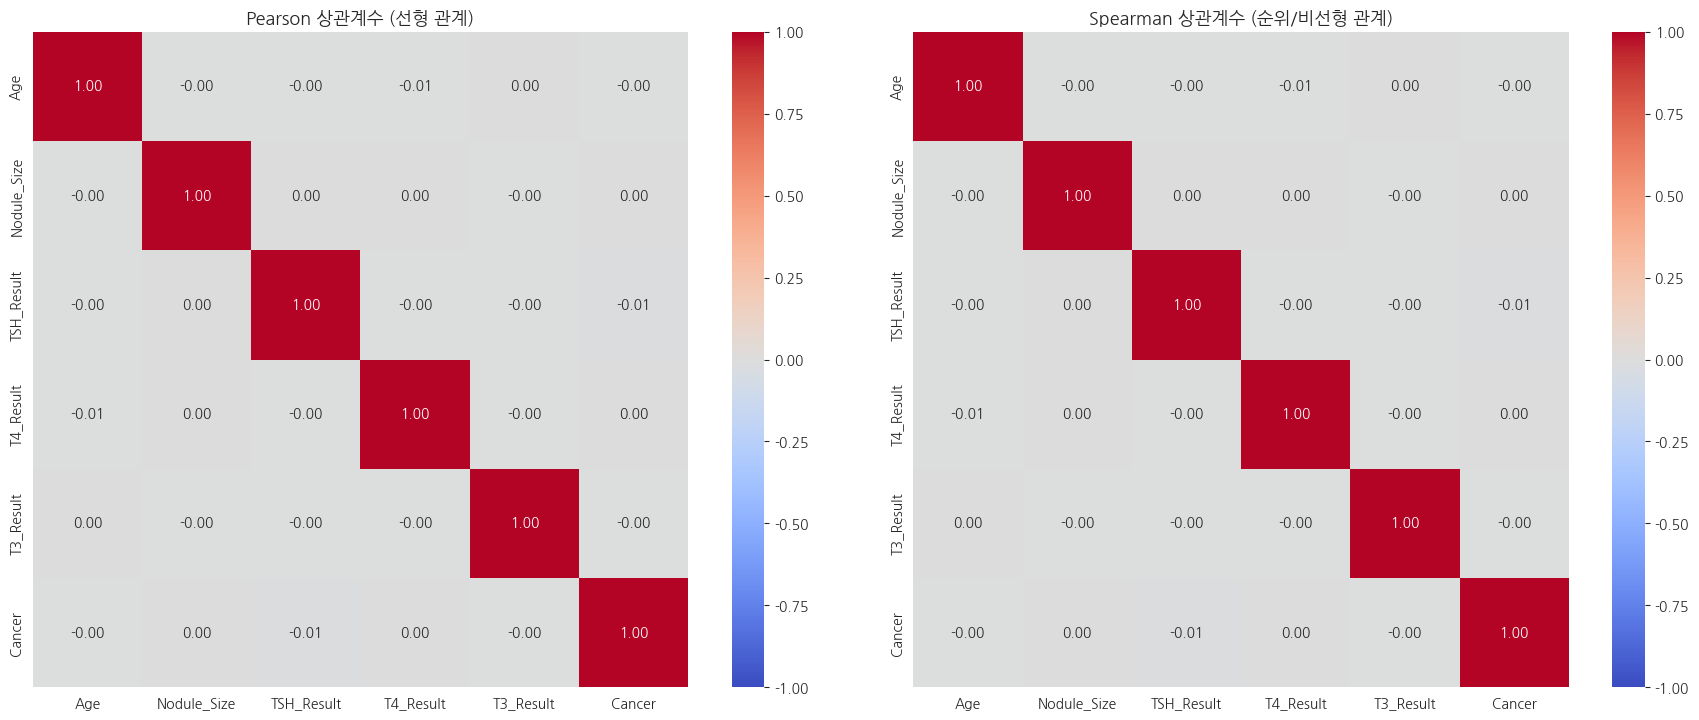

=== Pearson-Spearman 차이가 큰 변수쌍 Top 5 (비선형 관계 의심) ===


,,0
Age,TSH_Result,0.000021
Nodule_Size,T3_Result,0.000019
TSH_Result,T4_Result,0.000013
T4_Result,T3_Result,0.000013
Nodule_Size,T4_Result,0.000012


In [10]:
# ===== [셀 7] 피어슨 vs 스피어만 상관관계 히트맵 비교 =====
corr_cols = num_cols + [target_col]

pearson_corr = df[corr_cols].corr(method='pearson')
spearman_corr = df[corr_cols].corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(pearson_corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=axes[0], vmin=-1, vmax=1, square=True)
axes[0].set_title('Pearson 상관계수 (선형 관계)', fontsize=13)

sns.heatmap(spearman_corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=axes[1], vmin=-1, vmax=1, square=True)
axes[1].set_title('Spearman 상관계수 (순위/비선형 관계)', fontsize=13)

plt.tight_layout()
plt.show()

# 두 상관계수 차이가 큰 변수쌍 (비선형성 의심)
diff = (spearman_corr - pearson_corr).abs()
diff_unstack = diff.where(np.triu(np.ones(diff.shape), k=1).astype(bool)).stack().sort_values(ascending=False)
print("=== Pearson-Spearman 차이가 큰 변수쌍 Top 5 (비선형 관계 의심) ===")
display(diff_unstack.head(5))